Ders Adı: YZM212 Makine Öğrenmesi 

Ödev Başlığı: 2. Laboratuvar Ödevi: MLE ile Akıllı Şehir Planlaması 

Ad-Soyad: Ahmet Yusuf Pazarlıoğlu

Öğrenci Numarası: 23291203

Tarih: 15.03.2026

### Bölüm 1: Teorik Türetme (Analitik Çözüm)

Bölüm 1: Teorik ÇözümlerSenaryoya göre, şehrin en yoğun caddesinden bir dakikada geçen araç sayısı ($k$), Poisson Dağılımı ile modellenmektedir. Poisson olasılık fonksiyonu aşağıdaki gibidir:$$P(k|\lambda)=\frac{e^{-\lambda}\cdot\lambda^{k}}{k!}$$1. Likelihood (Olabilirlik) Fonksiyonunun Yazılması:
Elimizde $n$ adet gözlemden oluşan bağımsız bir veri seti $\{k_{1},k_{2},...,k_{n}\}$ bulunmaktadır. Tüm veri seti için Likelihood fonksiyonu $L(\lambda)$, tekil gözlemlerin olasılıklarının çarpımına eşittir:$$L(\lambda) = \prod_{i=1}^{n} P(k_i|\lambda) = \prod_{i=1}^{n} \frac{e^{-\lambda} \cdot \lambda^{k_i}}{k_i!}$$2. Log-Likelihood Fonksiyonunun Türetilmesi:
Hesaplama kolaylığı sağlamak için bu çarpım fonksiyonunun doğal logaritmasını alarak Log-Likelihood $l(\lambda)$ fonksiyonunu türetiyoruz:$$l(\lambda) = \ln(L(\lambda)) = \ln\left(\prod_{i=1}^{n} \frac{e^{-\lambda} \cdot \lambda^{k_i}}{k_i!}\right)$$Logaritma kuralları gereği, çarpımın logaritması toplamların logaritmasına dönüşür:$$l(\lambda) = \sum_{i=1}^{n} \ln\left(\frac{e^{-\lambda} \cdot \lambda^{k_i}}{k_i!}\right)$$$$l(\lambda) = \sum_{i=1}^{n} \left( \ln(e^{-\lambda}) + \ln(\lambda^{k_i}) - \ln(k_i!) \right)$$$$l(\lambda) = \sum_{i=1}^{n} \left( -\lambda + k_i \ln(\lambda) - \ln(k_i!) \right)$$Toplam sembolünü dağıttığımızda Log-Likelihood fonksiyonunun son halini elde ederiz:$$l(\lambda) = -n\lambda + \ln(\lambda)\sum_{i=1}^{n} k_i - \sum_{i=1}^{n} \ln(k_i!)$$3. Türev Alma ve $\hat{\lambda}_{MLE}$ Sonucuna Ulaşılması:
En iyi parametre tahminini bulmak için $l(\lambda)$ fonksiyonunun $\lambda$'ya göre türevini alıp sıfıra eşitliyoruz. Son terim (faktöriyelli kısım) $\lambda$ içermediği için türevi sıfırdır:$$\frac{d}{d\lambda} l(\lambda) = -n + \frac{1}{\lambda}\sum_{i=1}^{n} k_i$$Maksimum noktayı bulmak için türevi sıfıra eşitliyoruz:$$-n + \frac{1}{\lambda}\sum_{i=1}^{n} k_i = 0$$$$n = \frac{1}{\lambda}\sum_{i=1}^{n} k_i$$$$\hat{\lambda}_{MLE} = \frac{1}{n}\sum_{i=1}^{n} k_i$$Sonuç: Görüldüğü üzere, Poisson dağılımı için Maximum Likelihood Estimation ($\hat{\lambda}_{MLE}$) yöntemiyle bulunan optimal parametre değeri, verilerin aritmetik ortalamasına eşittir.

### Bölüm 2: Python ile Sayısal (Numerical) MLE

In [1]:
# Bağımlılıklar (Ödev kuralı: Kütüphaneler en başta import edilmeli)
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt

# Gözlemlenen Trafik Verisi (1 dakikada geçen araç sayısı)
traffic_data = np.array([12, 15, 10, 8, 14, 11, 13, 16, 9, 12, 11, 14, 10, 15])

def negative_log_likelihood(lam, data):
    """
    Poisson dağılımı için Negatif Log-Likelihood hesaplar.
    İpucu: log(k!) terimi optimizasyon sırasında sabit olduğu için ihmal edilebilir.
    """
    n = len(data)
    
    # opt.minimize 'lam' değerini bir dizi olarak gönderir, içinden değeri alıyoruz
    lambda_val = lam[0]
    
    # NLL Formülü: n * lambda - ln(lambda) * toplam(k_i)
    # log(k!) kısmı sabit olduğu için minimizasyona etkisi yoktur, formüle dahil edilmedi.
    nll = n * lambda_val - np.log(lambda_val) * np.sum(data)
    
    return nll

# Başlangıç tahmini (Optimizasyon algoritmasının aramaya başlayacağı nokta)
initial_guess = np.array([1.0])

# Optimizasyon: NLL'yi minimize etmek, Likelihood'u maximize etmektir.
# bounds=[(0.001, None)] ile lambda'nın 0'dan büyük olması gerektiğini belirtiyoruz.
result = opt.minimize(negative_log_likelihood, initial_guess, args=(traffic_data,), bounds=[(0.001, None)])

# Sonuçların ekrana yazdırılması
print(f"Sayısal Tahmin (MLE lambda): {result.x[0]:.4f}")
print(f"Analitik Tahmin (Ortalama): {np.mean(traffic_data):.4f}")

Sayısal Tahmin (MLE lambda): 12.1429
Analitik Tahmin (Ortalama): 12.1429


### Bölüm 3: Model Karşılaştırma ve Görselleştirme

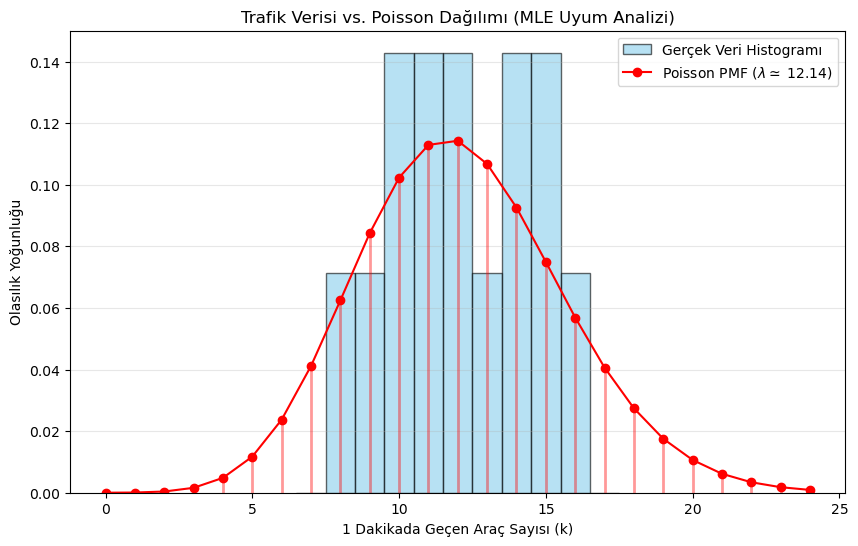

In [3]:
from scipy.stats import poisson

# Bulduğumuz en iyi lambda değeri
lambda_hat = result.x[0]

# K aralığını belirleme (Grafiğin x ekseni için 0'dan 25'e kadar araç sayısı)
k_values = np.arange(0, 25)

# Poisson PMF (Olasılık Kütle Fonksiyonu) hesaplama
pmf_values = poisson.pmf(k_values, mu=lambda_hat)

# Görselleştirme (plt kütüphanesi ile)
plt.figure(figsize=(10, 6))

# Gerçek verinin histogramı (density=True ile olasılığa dönüştürüyoruz ki PMF ile adil karşılaştırılabilsin)
# Bins ayarı çubukların tam tamsayıların üzerine oturmasını sağlar
plt.hist(traffic_data, bins=np.arange(6.5, 18.5, 1), density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Gerçek Veri Histogramı')

# Modelin PMF (Olasılık Kütle Fonksiyonu) grafiği
plt.plot(k_values, pmf_values, 'ro-', ms=6, label=rf'Poisson PMF ($\lambda \simeq$ {lambda_hat:.2f})')
plt.vlines(k_values, 0, pmf_values, colors='red', lw=2, alpha=0.4)

# Eksen isimleri, başlık ve gösterge (Ödev Zorunluluğu)
plt.xlabel('1 Dakikada Geçen Araç Sayısı (k)')
plt.ylabel('Olasılık Yoğunluğu')
plt.title('Trafik Verisi vs. Poisson Dağılımı (MLE Uyum Analizi)')
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Grafiği ekrana yazdırma
plt.show()

### Bölüm 4: Gerçek Hayat Senaryosu - "Outlier" Analizi

Veri setimize yanlışlıkla "200" gibi ekstrem bir aykırı değer (outlier) eklenmiş olsaydı, MLE yöntemiyle bulduğumuz $\hat{\lambda}$ parametresi bu durumdan çok şiddetli bir şekilde olumsuz etkilenirdi. Bölüm 1'de analitik olarak kanıtladığımız üzere, Poisson dağılımı için MLE tahmini doğrudan verilerin aritmetik ortalamasına eşittir. Aritmetik ortalama, yapısı gereği uç değerlere (outliers) karşı dirençli (robust) bir metrik değildir. Örneğin, mevcut 14 gözlemimizin toplamı 170 ve MLE tahmini $\lambda \simeq 12.14$'tür. Eğer 15. gözlem olarak "200" eklenirse, yeni parametre tahminimiz $\lambda = (170+200)/15 \simeq 24.66$ seviyesine fırlayacaktır.Belediyenin Trafik Planlamasındaki Etkisi:
Bu durum, caddedeki araç trafiğinin gerçekte olduğunun iki katıymış gibi algılanmasına yol açacaktır. Bu hatalı modele güvenen belediye yönetimi, trafiğin aşırı yoğun olduğu yanılgısına düşerek gereksiz bir yol genişletme kararı alabilir, bütçeyi ve kaynakları tamamen yanlış bir projeye israf edebilir. Bu senaryo, MLE tahmincisinin aykırı değerlere karşı ne kadar hassas olduğunu ve makine öğrenmesi süreçlerinde modelleme öncesi veri temizliği (data cleaning) ile anomali tespitinin ne denli kritik bir adım olduğunu açıkça göstermektedir.